In [180]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

In [181]:
# path of folder containing all boris/behavioral data
root_boris = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1"

### Taking folder with boris files and creating a dataframe with every recordings' boris

In [182]:
# Creating dataframe with all boris files looping through all files in the directory and converting to a dataframe and then concatenating them
boris_files = [os.path.join(root_boris, f) for f in os.listdir(root_boris) if f.endswith('.csv')]
boris_df = pd.DataFrame()
for file in boris_files:
    temp_df = pd.read_csv(file)
    boris_df = pd.concat([boris_df, temp_df], ignore_index=True)


boris_df.head()

,Observation id,Observation date,Description,Media file,Total length,FPS,Subject,Behavior,Behavioral category,Modifiers,...,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Observation duration by subject by observation,Media file name,Image index start,Image index stop,Image file path start,Image file path stop
0,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_...,715.39,13.0,subject,body sniffing,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_...,715.39,13.0,subject,anogenital sniffing,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_...,715.39,13.0,subject,body sniffing,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_...,715.39,13.0,subject,body sniffing,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RI1_s1_1_p5_2_nRB6_20250622_143958.1,2025-07-03 10:47:38,NaN,/Users/ayushjain/Downloads/RI1_s1_1_p5_2_nRB6_...,715.39,13.0,subject,anogenital sniffing,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Seperating subject and social agent

In [183]:
boris_df_agent = boris_df[boris_df['Subject'] == 'social_agent']
boris_df_subject = boris_df[boris_df['Subject'] == 'subject']

### Creating Seperate Dictionaries of each Behaviors' Start, Stop, and Duration. Does not include recording

#### Might include in class somewhere

In [184]:
def filter_boris_df(df):
    """
    Filters the boris dataframe for a specific behavior.
    Args:
        df (pd.DataFrame): The boris dataframe to filter.
        behavior (str): The behavior to filter for.
    Returns:
        pd.DataFrame: A filtered dataframe containing only the specified behavior.
    """

    # extract from cols 'Behavior' and 'Start (s)' and 'Stop (s)' into seperate dictionaries for each behavior
    behaviors = df['Behavior'].unique()
    print(f"Behaviors found: {behaviors}")

    behavior_dict = {}

    # Loop through each behavior and extract start and stop times
    for behavior in behaviors:
        filtered_df = df[df['Behavior'] == behavior] # filter the dataframe for the current behavior

        start_times = filtered_df['Start (s)'].values
        stop_times = filtered_df['Stop (s)'].values
        behavior_dict[behavior] = {'start': start_times, 'stop': stop_times, 'duration': stop_times - start_times}

    # print first n entries of the behavior_dict only showing first 5 start, stop, and duration times for each behavior
    for behavior, times in list(behavior_dict.items()):
        print(f"Behavior: {behavior}")
        print(f"Start times: {times['start'][:5]}")
        print(f"Stop times: {times['stop'][:5]}")
        print(f"Duration: {times['duration'][:5]}")
        print()

    return behavior_dict

In [185]:
behavior_dict_agent = filter_boris_df(boris_df_agent)

Behaviors found: ['body sniffing' 'facial sniffing' 'anogenital sniffing' 'fighting'
 'chasing' 'tails rattling' 'Posturing']
Behavior: body sniffing
Start times: [ 51.89  229.592 488.331  46.15   49.404]
Stop times: [ 52.639 231.327 490.831  46.904  51.404]
Duration: [0.749 1.735 2.5   0.754 2.   ]

Behavior: facial sniffing
Start times: [227.831 329.404  72.223 157.267 236.867]
Stop times: [229.078 329.655  75.223 160.067 237.867]
Duration: [1.247 0.251 3.    2.8   1.   ]

Behavior: anogenital sniffing
Start times: [ 85.902  92.153 228.906  85.222  81.   ]
Stop times: [ 87.654  93.904 231.156  92.717  81.533]
Duration: [1.752 1.751 2.25  7.495 0.533]

Behavior: fighting
Start times: [ 40.133 134.733 146.133 428.071 440.821]
Stop times: [ 42.067 144.067 152.    437.071 442.821]
Duration: [1.934 9.334 5.867 9.    2.   ]

Behavior: chasing
Start times: [437.071 347.    116.867 118.733 235.167]
Stop times: [438.567 347.767 117.533 118.967 236.467]
Duration: [1.496 0.767 0.666 0.234 1.3  

In [186]:
behavior_dict_subject = filter_boris_df(boris_df_subject)

Behaviors found: ['body sniffing' 'anogenital sniffing' 'facial sniffing' 'Posturing'
 'chasing']
Behavior: body sniffing
Start times: [ 6.846 17.385 29.538 37.615 42.462]
Stop times: [11.077 28.385 33.769 39.538 43.923]
Duration: [ 4.231 11.     4.231  1.923  1.461]

Behavior: anogenital sniffing
Start times: [13.231 36.231 40.923 54.769 58.692]
Stop times: [17.154 37.462 42.077 55.692 61.462]
Duration: [3.923 1.231 1.154 0.923 2.77 ]

Behavior: facial sniffing
Start times: [ 44.385  84.077  97.308 118.077 129.923]
Stop times: [ 47.769  94.385  98.077 121.923 132.308]
Duration: [ 3.384 10.308  0.769  3.846  2.385]

Behavior: Posturing
Start times: [151.567 433.821 439.322 441.571 442.822]
Stop times: [152.82  434.571 441.071 442.57  449.571]
Duration: [1.253 0.75  1.749 0.999 6.749]

Behavior: chasing
Start times: [72.9]
Stop times: [74.1]
Duration: [1.2]



In [187]:
behavior_counts = {}

# print length of each behavior
for behavior, times in behavior_dict_agent.items():
    behavior_counts[behavior] = len(times['start'])

# print behavior counts
for behavior, count in behavior_counts.items():
    print(f"Behavior: {behavior}, Count: {count}")

Behavior: body sniffing, Count: 215
Behavior: facial sniffing, Count: 196
Behavior: anogenital sniffing, Count: 81
Behavior: fighting, Count: 144
Behavior: chasing, Count: 30
Behavior: tails rattling, Count: 5
Behavior: Posturing, Count: 2


### Counting behaviors function, might include in an analysis class somewhere

In [188]:
def count_behaviors(behavior_dict):
        """
        Counts the number of behaviors for each behavior type in the behavior dictionary.
        
        Args:
                behavior_dict (dict): The behavior dictionary containing start and stop times for each behavior type.
                
        Returns:
                dict: A dictionary with behavior types as keys and their counts as values.
        """
        behavior_counts = {behavior: len(times['start']) for behavior, times in behavior_dict.items()}
        return behavior_counts

behavior_counts_agent = count_behaviors(behavior_dict_agent)
behavior_counts_subject = count_behaviors(behavior_dict_subject)

for behavior, count in behavior_counts_agent.items():
        print(f"Social Agent - {behavior}: {count} occurrences")
        
print()

for behavior, count in behavior_counts_subject.items():
        print(f"Subject - {behavior}: {count} occurrences")


Social Agent - body sniffing: 215 occurrences
Social Agent - facial sniffing: 196 occurrences
Social Agent - anogenital sniffing: 81 occurrences
Social Agent - fighting: 144 occurrences
Social Agent - chasing: 30 occurrences
Social Agent - tails rattling: 5 occurrences
Social Agent - Posturing: 2 occurrences

Subject - body sniffing: 213 occurrences
Subject - anogenital sniffing: 103 occurrences
Subject - facial sniffing: 138 occurrences
Subject - Posturing: 82 occurrences
Subject - chasing: 1 occurrences


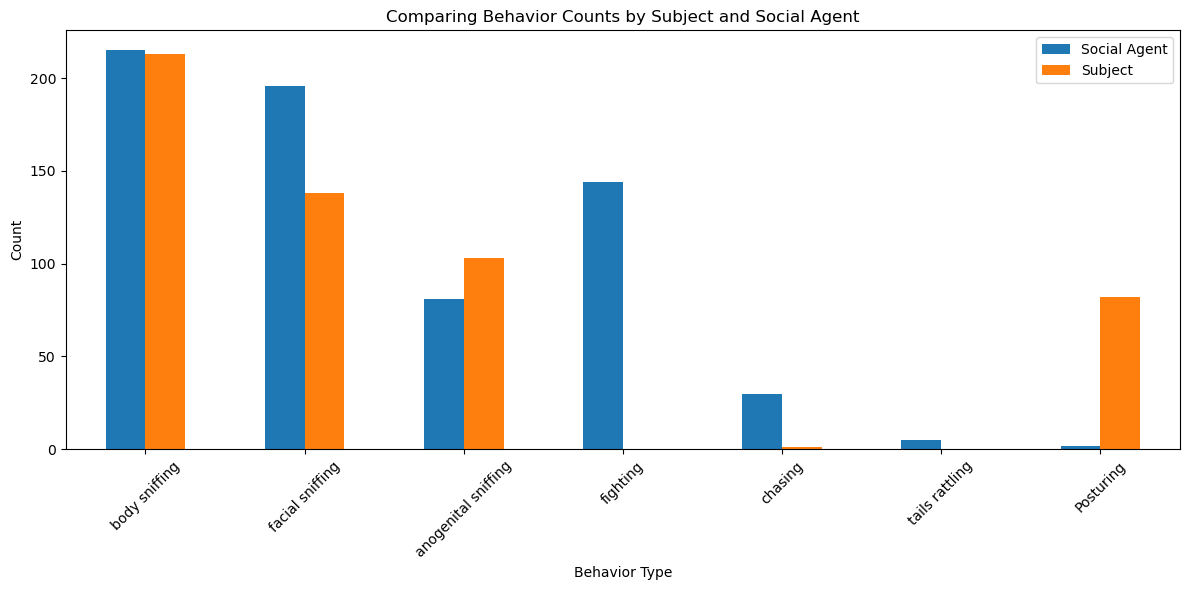

In [189]:

def plot_behavior_counts(behavior_counts_agent, behavior_counts_subject):
        """
        Plots the counts of behaviors for each behavior type for both the subject and social agent.
        
        Args:
                behavior_counts_agent (dict): A dictionary with behavior types as keys and their counts as values for the social agent.
                behavior_counts_subject (dict): A dictionary with behavior types as keys and their counts as values for the subject.
        """
        # Create a DataFrame from the behavior counts
        df_agent = pd.DataFrame.from_dict(behavior_counts_agent, orient='index', columns=['Social Agent'])
        df_subject = pd.DataFrame.from_dict(behavior_counts_subject, orient='index', columns=['Subject'])
        
        # Concatenate the two DataFrames
        df_combined = pd.concat([df_agent, df_subject], axis=1)
        
        # Plotting
        ax = df_combined.plot(kind='bar', figsize=(12, 6))
        ax.set_title('Comparing Behavior Counts by Subject and Social Agent')
        ax.set_ylabel('Count')
        ax.set_xlabel('Behavior Type')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
plot_behavior_counts(behavior_counts_agent, behavior_counts_subject)



In [190]:
# make sure everthing matches up
for behavior, times in behavior_dict_agent.items():
    if len(times['start']) != len(times['stop']):
        print(f"Behavior {behavior} has mismatched start and stop times.")
    else:
        print(f"Behavior {behavior} has matching start and stop times.")

print()

# make sure everthing matches up
for behavior, times in behavior_dict_subject.items():
    if len(times['start']) != len(times['stop']):
        print(f"Behavior {behavior} has mismatched start and stop times.")
    else:
        print(f"Behavior {behavior} has matching start and stop times.")

Behavior body sniffing has matching start and stop times.
Behavior facial sniffing has matching start and stop times.
Behavior anogenital sniffing has matching start and stop times.
Behavior fighting has matching start and stop times.
Behavior chasing has matching start and stop times.
Behavior tails rattling has matching start and stop times.
Behavior Posturing has matching start and stop times.

Behavior body sniffing has matching start and stop times.
Behavior anogenital sniffing has matching start and stop times.
Behavior facial sniffing has matching start and stop times.
Behavior Posturing has matching start and stop times.
Behavior chasing has matching start and stop times.


### Filtering out behaviors < 300ms (0.3s here)

In [191]:
# Filter out behaviors with duration less than 300ms
for behavior, times in behavior_dict_agent.items():
    durations = times['duration']
    valid_indices = durations >= 0.3  # 300ms
    behavior_dict_agent[behavior]['start'] = times['start'][valid_indices]
    behavior_dict_agent[behavior]['stop'] = times['stop'][valid_indices]
    behavior_dict_agent[behavior]['duration'] = durations[valid_indices]

# Filter out behaviors with duration less than 300ms
for behavior, times in behavior_dict_subject.items():
    durations = times['duration']
    valid_indices = durations >= 0.3  # 300ms
    behavior_dict_subject[behavior]['start'] = times['start'][valid_indices]
    behavior_dict_subject[behavior]['stop'] = times['stop'][valid_indices]
    behavior_dict_subject[behavior]['duration'] = durations[valid_indices]

### Finding latency between stop time of prior behavior and fighting for each behavior type

In [192]:
def calculate_latencies(behavior_dict, sub_behavior_dict, target_behavior='fighting'):
    """
    Calculate latencies between the end of the previous behavior and the start of the target behavior.
    
    Args:
        behavior_dict (dict): Dictionary containing behavior data with start and stop times.
        target_behavior (str): The behavior for which to calculate latencies.
        
    Returns:
        list: A list of dictionaries containing latency information.
    """
    latencies = []

    # For each start time of the target behavior
    for target_start in behavior_dict[target_behavior]['start']:
        latest_prior_stop = None

        for behavior, times in sub_behavior_dict.items():
            if behavior == target_behavior:
                continue  # skip the behavior we're measuring latency to

            stop_times = np.array(times['stop'])
            # Filter stops that occurred before the target start
            prior_stops = stop_times[stop_times < target_start]

            if prior_stops.size > 0:
                max_prior_stop = np.max(prior_stops)
                latency = target_start - max_prior_stop
                latencies.append({
                    'from_behavior': behavior,
                    'to_behavior': target_behavior,
                    'latency': latency,
                    'prior_stop_time': max_prior_stop,
                    'target_start_time': target_start
                })

    return latencies

latency_subj_beh_to_fight = calculate_latencies(behavior_dict_agent, behavior_dict_subject)

### latencies for subject behavior to fight and then social agents behavior to fight

In [193]:
latency_subj_beh_to_fight = calculate_latencies(behavior_dict_agent, behavior_dict_subject)
latency_agent_beh_to_fight = calculate_latencies(behavior_dict_agent, behavior_dict_agent)

In [194]:
# print out information about the latencies
print("Subject behavior to fight first 5\n")
for latency in latency_subj_beh_to_fight[:5]:
    print(f"From {latency['from_behavior']} to {latency['to_behavior']}: "
          f"Latency = {latency['latency']:.3f}s, "
          f"Prior Stop = {latency['prior_stop_time']:.3f}s, "
          f"Target Start = {latency['target_start_time']:.3f}s")
    
print("\nagent behav to fight first 5\n")

for latency in latency_agent_beh_to_fight[:5]:
    print(f"From {latency['from_behavior']} to {latency['to_behavior']}: "
          f"Latency = {latency['latency']:.3f}s, "
          f"Prior Stop = {latency['prior_stop_time']:.3f}s, "
          f"Target Start = {latency['target_start_time']:.3f}s")

Subject behavior to fight first 5

From body sniffing to fighting: Latency = 0.200s, Prior Stop = 39.933s, Target Start = 40.133s
From anogenital sniffing to fighting: Latency = 0.234s, Prior Stop = 39.899s, Target Start = 40.133s
From facial sniffing to fighting: Latency = 0.833s, Prior Stop = 39.300s, Target Start = 40.133s
From Posturing to fighting: Latency = 15.900s, Prior Stop = 24.233s, Target Start = 40.133s
From body sniffing to fighting: Latency = 4.000s, Prior Stop = 130.733s, Target Start = 134.733s

agent behav to fight first 5

From body sniffing to fighting: Latency = 0.066s, Prior Stop = 40.067s, Target Start = 40.133s
From facial sniffing to fighting: Latency = 2.333s, Prior Stop = 37.800s, Target Start = 40.133s
From anogenital sniffing to fighting: Latency = 3.066s, Prior Stop = 37.067s, Target Start = 40.133s
From chasing to fighting: Latency = 19.033s, Prior Stop = 21.100s, Target Start = 40.133s
From Posturing to fighting: Latency = 4.233s, Prior Stop = 35.900s, T

### Unfinished Ignore

In [195]:
# finding the average latency for each behavior type
def categorize_latencies(latencies):
    """
    Categorizes latencies into different bins based on their values.
    
    Args:
        latencies (list): List of latency dictionaries.
        
    Returns:
        dict: A dictionary with categories as keys and lists of latencies as values.
    """
    categorized = {'<0.5s': [], '0.5s-1s': [], '1s-2s': [], '>2s': []}

    for entry in latencies:
        latency = entry['latency']
        if latency < 0.5:
            categorized['<0.5s'].append(entry)
        elif 0.5 <= latency < 1:
            categorized['0.5s-1s'].append(entry)
        elif 1 <= latency < 2:
            categorized['1s-2s'].append(entry)
        else:
            categorized['>2s'].append(entry)

    return categorized

In [196]:
categorized_latencies = categorize_latencies(latency_subj_beh_to_fight)

In [208]:
# printing categorized latencies
for category, entries in categorized_latencies.items():
    print(f"Category: {category}, Count: {len(entries)}")
    for entry in entries[:5]:  # Print first 5 entries in each category
        print(f"  From {entry['from_behavior']} to {entry['to_behavior']}: "
              f"Latency = {entry['latency']:.3f}s, "
              f"Prior Stop = {entry['prior_stop_time']:.3f}s, "
              f"Target Start = {entry['target_start_time']:.3f}s")
    print()


Category: <0.5s, Count: 45
  From body sniffing to fighting: Latency = 0.200s, Prior Stop = 39.933s, Target Start = 40.133s
  From anogenital sniffing to fighting: Latency = 0.234s, Prior Stop = 39.899s, Target Start = 40.133s
  From facial sniffing to fighting: Latency = 0.359s, Prior Stop = 440.462s, Target Start = 440.821s
  From facial sniffing to fighting: Latency = 0.334s, Prior Stop = 107.033s, Target Start = 107.367s
  From facial sniffing to fighting: Latency = 0.200s, Prior Stop = 112.467s, Target Start = 112.667s

Category: 0.5s-1s, Count: 47
  From facial sniffing to fighting: Latency = 0.833s, Prior Stop = 39.300s, Target Start = 40.133s
  From body sniffing to fighting: Latency = 0.500s, Prior Stop = 145.633s, Target Start = 146.133s
  From facial sniffing to fighting: Latency = 0.917s, Prior Stop = 583.154s, Target Start = 584.071s
  From body sniffing to fighting: Latency = 0.680s, Prior Stop = 150.153s, Target Start = 150.833s
  From Posturing to fighting: Latency = 0.

In [209]:
# same thing except only chasing behavior and fighting behavior printed
def categorize_latencies_chasing(latencies):
    """
    Categorizes latencies into different bins based on their values, focusing on 'chasing' behavior.
    
    Args:
        latencies (list): List of latency dictionaries.
        
    Returns:
        dict: A dictionary with categories as keys and lists of latencies as values.
    """
    categorized = {'<0.5s': [], '0.5s-1s': [], '1s-2s': [], '>2s': []}

    for entry in latencies:
        if entry['from_behavior'] != 'chasing':
            continue  # Skip if the behavior is not 'chasing'
        
        latency = entry['latency']
        if latency < 0.5:
            categorized['<0.5s'].append(entry)
        elif 0.5 <= latency < 1:
            categorized['0.5s-1s'].append(entry)
        elif 1 <= latency < 2:
            categorized['1s-2s'].append(entry)
        else:
            categorized['>2s'].append(entry)

    return categorized

categorized_latencies_chasing = categorize_latencies_chasing(latency_subj_beh_to_fight)
# printing categorized latencies for chasing behavior
for category, entries in categorized_latencies_chasing.items():
    print(f"Category: {category}, Count: {len(entries)}")
    for entry in entries[:5]:  # Print first 5 entries in each category
        print(f"  From {entry['from_behavior']} to {entry['to_behavior']}: "
              f"Latency = {entry['latency']:.3f}s, "
              f"Prior Stop = {entry['prior_stop_time']:.3f}s, "
              f"Target Start = {entry['target_start_time']:.3f}s")
    print()

Category: <0.5s, Count: 0

Category: 0.5s-1s, Count: 0

Category: 1s-2s, Count: 0

Category: >2s, Count: 119
  From chasing to fighting: Latency = 60.633s, Prior Stop = 74.100s, Target Start = 134.733s
  From chasing to fighting: Latency = 72.033s, Prior Stop = 74.100s, Target Start = 146.133s
  From chasing to fighting: Latency = 353.971s, Prior Stop = 74.100s, Target Start = 428.071s
  From chasing to fighting: Latency = 366.721s, Prior Stop = 74.100s, Target Start = 440.821s
  From chasing to fighting: Latency = 414.718s, Prior Stop = 74.100s, Target Start = 488.818s



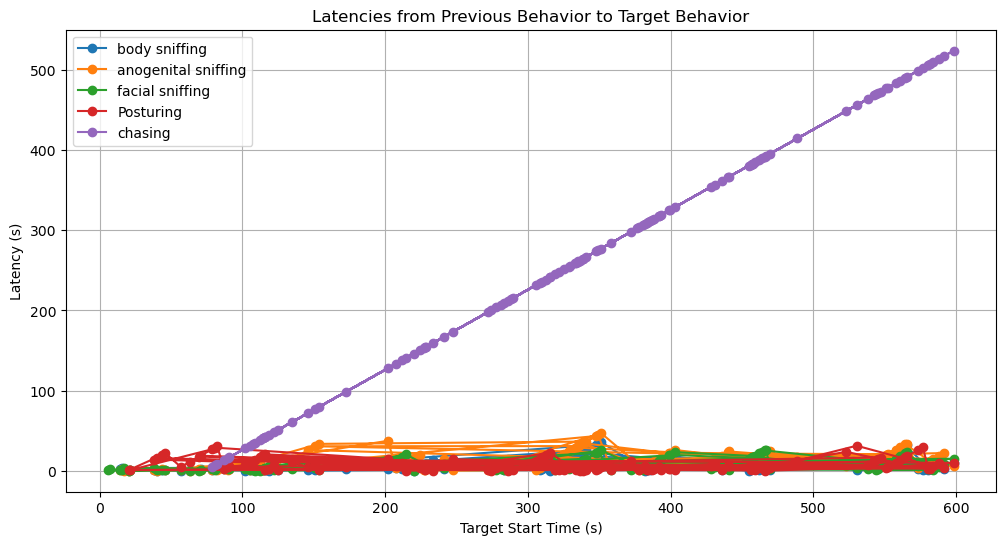

In [198]:
'''
 Plotting latencies for the social agent for each behavior type
 with latency_subj_beh_to_fight being a list containing dictionaries with the following keys

'from_behavior': behavior,
'to_behavior': target_behavior,
'latency': latency,
'prior_stop_time': max_prior_stop,
'target_start_time': target_start

'''
# plotting for above description
def plot_latencies(latencies):
    """
    Plot latencies for each behavior type.
    
    Args:
        latencies (list): List of dictionaries containing latency data.
    """
    # Create a DataFrame from the latencies
    df = pd.DataFrame(latencies)

    # Plotting
    plt.figure(figsize=(12, 6))
    for behavior in df['from_behavior'].unique():
        subset = df[df['from_behavior'] == behavior]
        plt.plot(subset['target_start_time'], subset['latency'], marker='o', label=behavior)

    plt.title('Latencies from Previous Behavior to Target Behavior')
    plt.xlabel('Target Start Time (s)')
    plt.ylabel('Latency (s)')
    plt.legend()
    plt.grid()
    plt.show()

plot_latencies(latency_subj_beh_to_fight)

In [199]:
# finding average latency for each behavior type
def average_latencies(latencies):
    """
    Calculate the average latency for each behavior type.
    
    Args:
        latencies (list): List of dictionaries containing latency data.
        
    Returns:
        dict: A dictionary with behavior types as keys and their average latencies as values.
    """
    avg_latencies = {}
    
    for entry in latencies:
        behavior = entry['from_behavior']
        if behavior not in avg_latencies:
            avg_latencies[behavior] = []
        avg_latencies[behavior].append(entry['latency'])
    
    # Calculate the average for each behavior
    for behavior, latency_list in avg_latencies.items():
        avg_latencies[behavior] = np.mean(latency_list)
    
    return avg_latencies


### Average latency for each behavior

In [200]:
# avg latencies for subject behavior to fight
avg_latencies_subj_beh_to_fight = average_latencies(latency_subj_beh_to_fight)

avg_latencies_agent_beh_to_fight = average_latencies(latency_agent_beh_to_fight)

In [203]:
# plot average latencies for each behavior type
def plot_average_latencies(avg_latencies, remove = None):
    """
    Plot average latencies for each behavior type.
    
    Args:
        avg_latencies (dict): A dictionary with behavior types as keys and their average latencies as values.
        remove (list, optional): A list of behavior types to exclude from the plot. Defaults to None.
    """
    behaviors = list(avg_latencies.keys())
    if remove is not None:
        behaviors = [b for b in behaviors if b not in remove]
    latencies = list(avg_latencies.values())
    if remove is not None:
        latencies = [avg_latencies[b] for b in behaviors]
    
    plt.figure(figsize=(12, 6))
    plt.bar(behaviors, latencies, color='skyblue')
    plt.title('Average Latency for Each Behavior Type')
    plt.xlabel('Behavior Type')
    plt.ylabel('Average Latency (s)')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


## Average Latency between behavior last and fight in subj

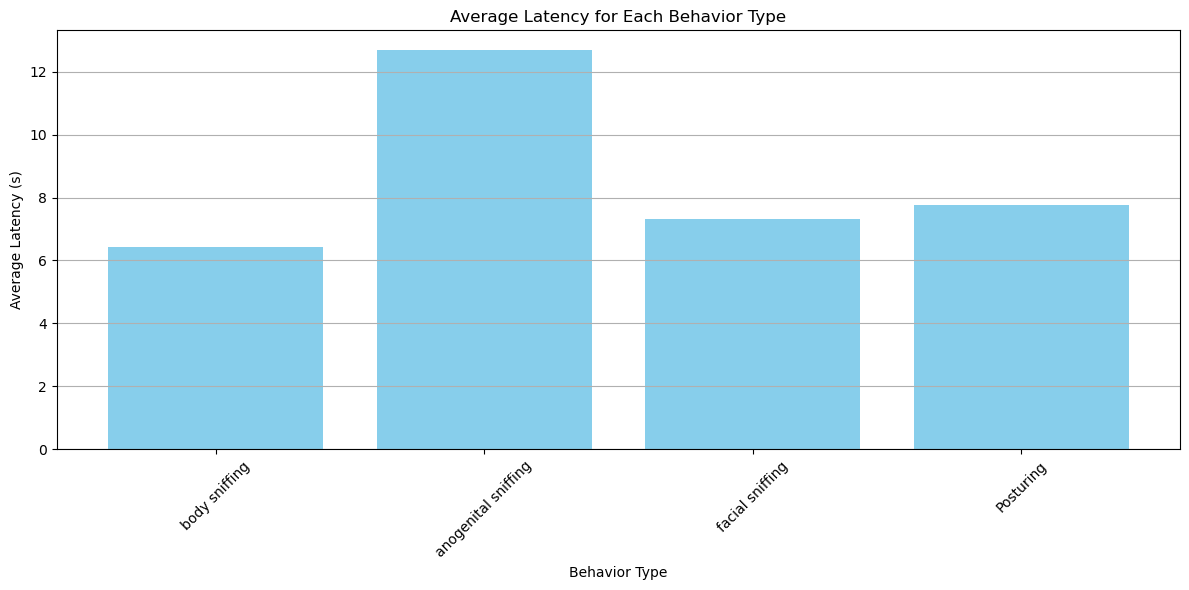

In [204]:
plot_average_latencies(avg_latencies_subj_beh_to_fight, ['chasing'])

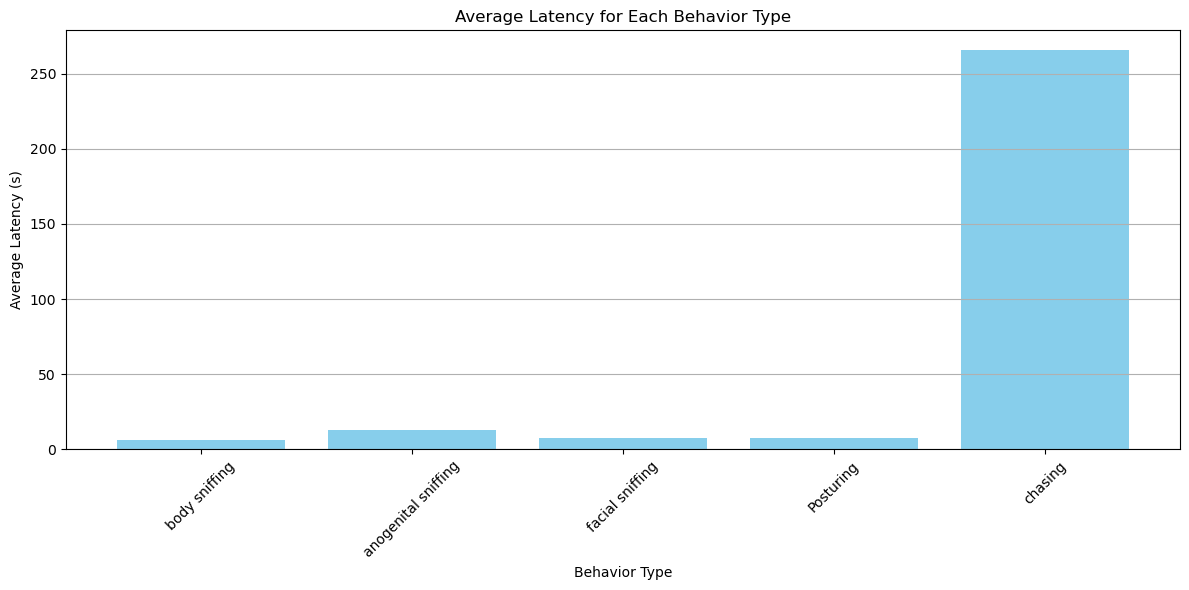

In [205]:
plot_average_latencies(avg_latencies_subj_beh_to_fight)

## Average Latency between behavior last and fight in agent

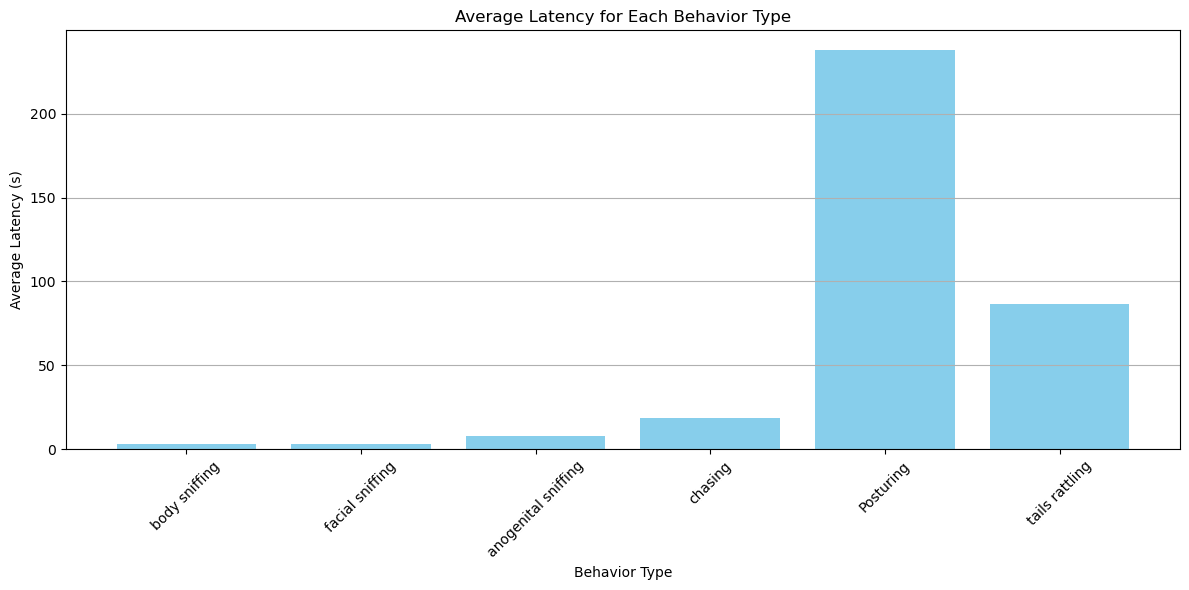

In [ ]:
plot_average_latencies(avg_latencies_agent_beh_to_fight)